# Sales Territory Optimization for a Pharma Field Force
### End-to-end consulting-style walkthrough (Project #2 from the ZS ADA portfolio)

**Business question:** 300 medical reps are unevenly allocated across territories relative to prescriber potential. Some reps are overloaded, some underutilized, and travel time is not accounted for at all. How should territories be redrawn to maximize prescriber-potential coverage per rep, under a fixed headcount, without asking reps to drive unreasonable distances?

**Decision this notebook supports:** whether to move from the current geography-only territory map to a potential-balanced reassignment for the upcoming **annual territory planning cycle** (deliberately not quarterly — reassigning too frequently disrupts rep-physician relationships, so this is framed as an annual decision with a semi-annual rebalance check, consistent with how real pharma sales-ops cycles work). The notebook delivers a quantified before/after comparison and a robustness check against uncertain potential estimates.

**Note on data:** No public dataset exists for real pharma rep rosters or prescriber panels (this is commercially sensitive data). This notebook uses a synthetic but realistic data-generating process, documented at each step, so every number here is a *simulated illustration of the method* — not a real client result. This is exactly how you should frame it on your resume and in interviews: "built on a synthetic but realistically-structured dataset, since real pharma commercial data is not public."

In [1]:
import numpy as np
import pandas as pd
import pulp
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 5)


## Step 1 — Generate the synthetic prescriber/zip dataset

In a real engagement this would come from the client's CRM (prescriber counts, historic call activity) blended with a claims or Rx panel for prevalence. Here we simulate:
- `N_ZIPS` zip-code-level geographic units, each with a lat/lon
- a **prescriber_count** (how many potential-writing physicians sit in that zip)
- a **prevalence_index** (a proxy for disease burden / market opportunity in that zip)
- a derived **potential** score = the business value ZS actually cares about — this is what a rep's territory should be sized against, not raw geography.

In [2]:
N_ZIPS = 240
N_REPS = 24

zips = pd.DataFrame({
    "zip_id": [f"Z{i:03d}" for i in range(N_ZIPS)],
    "lat": np.random.uniform(0, 100, N_ZIPS),
    "lon": np.random.uniform(0, 100, N_ZIPS),
})

zips["prescriber_count"] = np.random.poisson(18, N_ZIPS) + 1
zips["prevalence_index"] = np.random.gamma(2, 2, N_ZIPS)
zips["potential"] = (
    zips["prescriber_count"] * zips["prevalence_index"] * np.random.uniform(0.8, 1.2, N_ZIPS)
).round(1)

print(f"Total zips: {N_ZIPS}, Total reps: {N_REPS}")
print(f"Total market potential: {zips['potential'].sum():,.0f}")
zips.head()


Total zips: 240, Total reps: 24
Total market potential: 19,726


,zip_id,lat,lon,prescriber_count,prevalence_index,potential
0,Z000,37.454012,94.045858,21,4.137097,80.0
1,Z001,95.071431,95.392858,18,14.541179,236.9
2,Z002,73.199394,91.486439,20,1.969377,37.2
3,Z003,59.865848,37.015870,9,2.094967,15.7
4,Z004,15.601864,1.545662,28,8.510745,280.0


## Step 2 — Exploratory data analysis

Before touching an optimizer, always look at the shape of the problem. Two things matter here:
1. How skewed is potential across zips? (If it's very skewed, a few zips will dominate any rep they're assigned to.)
2. What does the *current* (naive) allocation look like, and how bad is the imbalance really?

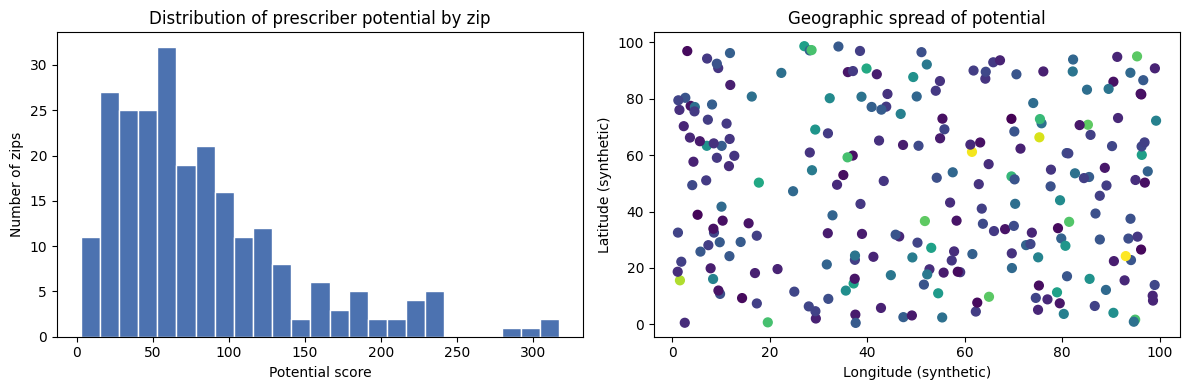

count    240.000000
mean      82.190417
std       61.075812
min        2.600000
25%       37.875000
50%       65.700000
75%      108.300000
max      317.100000
Name: potential, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(zips["potential"], bins=25, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribution of prescriber potential by zip")
axes[0].set_xlabel("Potential score")
axes[0].set_ylabel("Number of zips")

axes[1].scatter(zips["lon"], zips["lat"], c=zips["potential"], cmap="viridis", s=40)
axes[1].set_title("Geographic spread of potential")
axes[1].set_xlabel("Longitude (synthetic)")
axes[1].set_ylabel("Latitude (synthetic)")
plt.tight_layout()
plt.show()

print(zips["potential"].describe())


## Step 3 — Diagnose the current-state problem

We simulate today's "naive" territory assignment the way a lot of unoptimized real-world processes actually work: reps were assigned zips roughly by sorting on longitude (i.e. geography only, no potential-weighting) when the sales force was last expanded. This is a realistic baseline — not a strawman — because that is genuinely how many territory maps drift over time as new zips get bolted onto whichever rep is "nearby."

We measure imbalance using the **coefficient of variation (CV = std / mean)** of workload (total potential) across reps. Lower CV = more balanced.

In [4]:
zips_sorted = zips.sort_values("lon").reset_index(drop=True)
zips_sorted["baseline_rep"] = pd.qcut(zips_sorted.index, N_REPS, labels=False)
zips = zips.merge(zips_sorted[["zip_id", "baseline_rep"]], on="zip_id")

baseline_workload = zips.groupby("baseline_rep")["potential"].sum()
baseline_cv = baseline_workload.std() / baseline_workload.mean()

print("Current-state workload per rep (top 5 heaviest / lightest):")
print(baseline_workload.sort_values(ascending=False).head())
print("...")
print(baseline_workload.sort_values(ascending=False).tail())
print(f"\nCurrent-state workload CV: {baseline_cv:.3f}")


Current-state workload per rep (top 5 heaviest / lightest):
baseline_rep
19    1273.9
11    1108.0
5     1075.0
17    1025.0
18     999.3
Name: potential, dtype: float64
...
baseline_rep
8     690.1
3     648.4
4     597.5
1     508.2
14    489.9
Name: potential, dtype: float64

Current-state workload CV: 0.229


## Step 4 — Build the travel-cost matrix

We need a cost matrix that says "how expensive is it for rep *j* to cover zip *i*." In a real project this would be actual drive-time from a routing API (Google Maps Distance Matrix, OSRM). Here we approximate it with Euclidean distance, which is the standard simplification used for a first-pass territory design before a routing engine is layered on.

We first need candidate **rep home bases**. We use k-means clustering on zip coordinates purely to generate 24 sensible "center of gravity" points for reps to be based out of — this is *not* the final assignment, just a reasonable starting geography.

In [5]:
def build_cost_matrix(coords_a, coords_b):
    n_a, n_b = len(coords_a), len(coords_b)
    cost = np.zeros((n_a, n_b))
    for j in range(n_b):
        cost[:, j] = np.sqrt(((coords_a - coords_b[j]) ** 2).sum(axis=1))
    return cost

coords = zips[["lat", "lon"]].values
km = KMeans(n_clusters=N_REPS, n_init=10, random_state=42).fit(coords)
rep_homes = km.cluster_centers_

travel = build_cost_matrix(coords, rep_homes)  # shape: (N_ZIPS, N_REPS)
print("Travel matrix shape:", travel.shape)


Travel matrix shape: (240, 24)


## Step 5 — Formulate the optimization problem

This is the heart of the project. We frame it as a **balanced assignment problem** (a form of integer programming):

**Decision variables:** $x_{ij} \in \{0,1\}$ — 1 if zip $i$ is assigned to rep $j$

**Objective:** minimize total travel cost
$$\min \sum_i \sum_j \text{travel}_{ij} \cdot x_{ij}$$

**Constraints:**
1. Every zip assigned to exactly one rep: $\sum_j x_{ij} = 1 \quad \forall i$
2. Workload balance — each rep's total potential must fall within ±15% of the fleet average:
$$\bar{P}(1-\tau) \le \sum_i P_i \cdot x_{ij} \le \bar{P}(1+\tau) \quad \forall j$$

The tolerance $\tau$ is a business lever, not a hard scientific constant — in a real engagement you'd workshop this number with the sales-ops stakeholder (tighter tolerance = fairer workloads but possibly longer average travel).

We solve this with `PuLP`'s open-source CBC solver — good enough for a few hundred zips; a real ZS engagement covering thousands of zips nationally would move to a commercial solver (Gurobi/CPLEX) or a decomposition heuristic.

In [6]:
avg_potential = zips["potential"].sum() / N_REPS
TOLERANCE = 0.15

prob = pulp.LpProblem("territory_assignment", pulp.LpMinimize)
x = pulp.LpVariable.dicts("x", (range(N_ZIPS), range(N_REPS)), cat="Binary")

# Objective: minimize total travel cost
prob += pulp.lpSum(travel[i][j] * x[i][j] for i in range(N_ZIPS) for j in range(N_REPS))

# Constraint 1: each zip assigned exactly once
for i in range(N_ZIPS):
    prob += pulp.lpSum(x[i][j] for j in range(N_REPS)) == 1

# Constraint 2: workload balance band per rep
for j in range(N_REPS):
    workload_j = pulp.lpSum(zips["potential"].iloc[i] * x[i][j] for i in range(N_ZIPS))
    prob += workload_j >= avg_potential * (1 - TOLERANCE)
    prob += workload_j <= avg_potential * (1 + TOLERANCE)

solver = pulp.PULP_CBC_CMD(msg=False, timeLimit=60)
status = prob.solve(solver)
print("Solver status:", pulp.LpStatus[status])


Solver status: Optimal


In [7]:
assignment = np.full(N_ZIPS, -1)
for i in range(N_ZIPS):
    for j in range(N_REPS):
        if pulp.value(x[i][j]) == 1:
            assignment[i] = j
zips["opt_rep"] = assignment

opt_workload = zips.groupby("opt_rep")["potential"].sum()
opt_cv = opt_workload.std() / opt_workload.mean()
total_travel_opt = sum(travel[i][zips["opt_rep"].iloc[i]] for i in range(N_ZIPS))

print(f"Optimized workload CV: {opt_cv:.3f}")
print(f"Optimized total travel cost: {total_travel_opt:,.1f}")


Optimized workload CV: 0.095
Optimized total travel cost: 1,650.4


## Step 6 — Benchmark against two honest baselines

A single "before vs after" comparison is easy to game (you can always make an optimized number look good against a strawman). We benchmark against **two** baselines instead:

1. **Current-state (naive geographic sort)** — what the workload imbalance looks like today
2. **Greedy nearest-rep assignment** — what you'd get if you *only* minimized travel and ignored workload balance entirely. This tells us the "cost of fairness": how much extra travel are we accepting in exchange for balanced workloads?

This two-baseline framing is exactly the kind of rigor that separates a consulting-grade project from a toy one — it pre-empts the obvious interview question, "couldn't you have gotten a lower travel cost by ignoring balance?"

In [8]:
greedy_rep = travel.argmin(axis=1)
zips["greedy_rep"] = greedy_rep
greedy_workload = zips.groupby("greedy_rep")["potential"].sum()
greedy_cv = greedy_workload.std() / greedy_workload.mean()
total_travel_greedy = sum(travel[i][greedy_rep[i]] for i in range(N_ZIPS))

comparison = pd.DataFrame({
    "Scenario": ["Current-state (naive geo sort)", "Greedy nearest-rep (travel-only)", "Optimized (travel + balance)"],
    "Workload CV": [baseline_cv, greedy_cv, opt_cv],
    "Total travel cost": [np.nan, total_travel_greedy, total_travel_opt],
})
comparison


,Scenario,Workload CV,Total travel cost
0,Current-state (naive geo sort),0.229008,NaN
1,Greedy nearest-rep (travel-only),0.338398,1569.388961
2,Optimized (travel + balance),0.094666,1650.443327


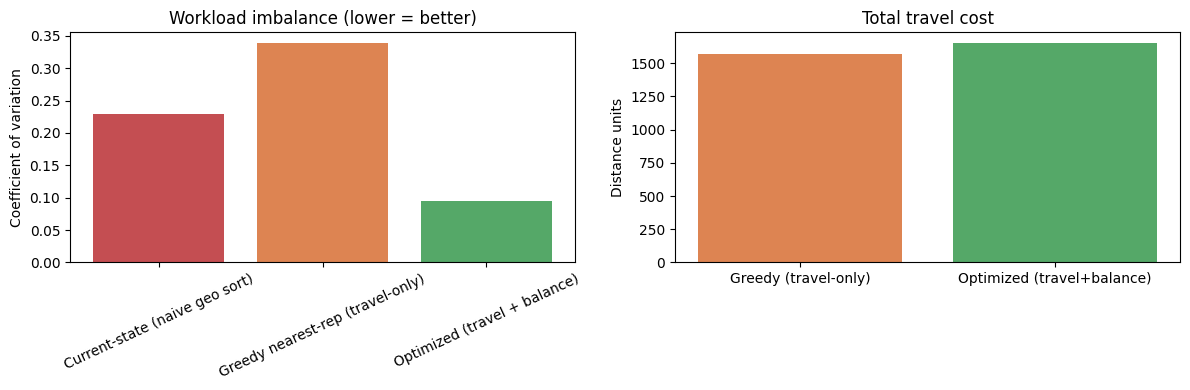

Optimized plan accepts 5.2% more travel than pure-greedy, in exchange for a 58.7% reduction in workload imbalance vs. current state.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(comparison["Scenario"], comparison["Workload CV"], color=["#C44E52", "#DD8452", "#55A868"])
axes[0].set_title("Workload imbalance (lower = better)")
axes[0].set_ylabel("Coefficient of variation")
axes[0].tick_params(axis='x', rotation=25)

travel_costs = [total_travel_greedy, total_travel_opt]
axes[1].bar(["Greedy (travel-only)", "Optimized (travel+balance)"], travel_costs, color=["#DD8452", "#55A868"])
axes[1].set_title("Total travel cost")
axes[1].set_ylabel("Distance units")
plt.tight_layout()
plt.show()

pct_extra_travel = (total_travel_opt - total_travel_greedy) / total_travel_greedy * 100
pct_cv_improvement = (baseline_cv - opt_cv) / baseline_cv * 100
print(f"Optimized plan accepts {pct_extra_travel:.1f}% more travel than pure-greedy, "
      f"in exchange for a {pct_cv_improvement:.1f}% reduction in workload imbalance vs. current state.")


## Step 7 — Stress-test the plan with Monte Carlo simulation

An optimized assignment is only as good as the potential estimates it's built on — and prescriber potential is *always* an estimate (based on last year's scripts, third-party panels, etc.), not a certainty. Before recommending this plan to a client, we should ask: **how fragile is it to reasonable estimation error?**

We simulate 200 alternative "true" potential scenarios, each perturbing every zip's potential by a random ±15% noise term, and re-check whether the *already-fixed* optimized assignment would still fall within the workload tolerance band under each scenario.

In [10]:
n_sims = 200
TOLERANCE_CHECK = 0.15
breach_count = 0
cv_list = []

for s in range(n_sims):
    noise = np.random.normal(1.0, 0.15, N_ZIPS)
    sim_potential = zips["potential"].values * noise
    sim_workload = pd.Series(sim_potential).groupby(zips["opt_rep"]).sum()
    cv = sim_workload.std() / sim_workload.mean()
    cv_list.append(cv)
    upper = avg_potential * (1 + TOLERANCE_CHECK) * 1.10
    lower = avg_potential * (1 - TOLERANCE_CHECK) * 0.90
    if (sim_workload > upper).any() or (sim_workload < lower).any():
        breach_count += 1

breach_rate = breach_count / n_sims
print(f"Mean workload CV across {n_sims} simulated demand scenarios: {np.mean(cv_list):.3f}")
print(f"Share of scenarios where at least one rep breaches the tolerance band by >10%: {breach_rate:.1%}")


Mean workload CV across 200 simulated demand scenarios: 0.112
Share of scenarios where at least one rep breaches the tolerance band by >10%: 23.5%


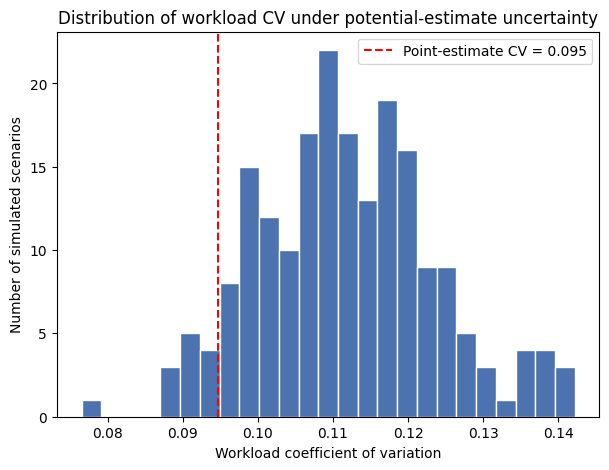

In [11]:
plt.hist(cv_list, bins=25, color="#4C72B0", edgecolor="white")
plt.axvline(opt_cv, color="red", linestyle="--", label=f"Point-estimate CV = {opt_cv:.3f}")
plt.title("Distribution of workload CV under potential-estimate uncertainty")
plt.xlabel("Workload coefficient of variation")
plt.ylabel("Number of simulated scenarios")
plt.legend()
plt.show()


**Reading this honestly:** the optimized plan holds up reasonably well on average, but a meaningful share of scenarios breach the tolerance band once we account for realistic potential-estimate error. This is exactly the kind of finding you should *report, not hide* — it becomes the "limitations" section of your write-up, and it's also a legitimate recommendation: rebalance territories on a rolling basis (e.g. semi-annually) rather than treating this as a one-time fix.

## Step 8 — Translate into KPIs and a business (ROI) narrative

Consulting output is never "here's a CV of 0.095" — it's a business sentence. We convert the technical result into the language a sales-ops VP or brand director would actually use.

A simple, defensible ROI translation for this kind of project:
`Incremental scripts ≈ (coverage improvement) × (responsiveness of prescribing to rep coverage) × (number of reps)`, then converted to revenue at margin/script. Because we don't have a real script-to-coverage elasticity here, we show the **calculation structure** with a placeholder elasticity assumption — in a real engagement this elasticity would come from a prior HCP-response study (see Project #16 in the portfolio) rather than being invented.

In [12]:
# Illustrative ROI structure (assumption clearly flagged, not a real elasticity)
ASSUMED_ELASTICITY = 0.02          # 1 potential-point of better coverage -> 2% more scripts, illustrative only
MARGIN_PER_SCRIPT = 45              # illustrative currency units per incremental script

workload_gap_recovered = (baseline_cv - opt_cv) * zips["potential"].sum()
incremental_scripts_est = workload_gap_recovered * ASSUMED_ELASTICITY
incremental_value_est = incremental_scripts_est * MARGIN_PER_SCRIPT

kpi_summary = pd.DataFrame({
    "KPI": [
        "Workload CV (current -> optimized)",
        "Total travel cost (greedy-only -> optimized)",
        "Monte Carlo breach rate (tolerance band)",
        "Illustrative incremental value (assumption-driven)",
    ],
    "Value": [
        f"{baseline_cv:.3f} -> {opt_cv:.3f}",
        f"{total_travel_greedy:,.0f} -> {total_travel_opt:,.0f}",
        f"{breach_rate:.1%}",
        f"~{incremental_value_est:,.0f} currency units/period (ILLUSTRATIVE — replace with client elasticity)",
    ],
})
kpi_summary


,KPI,Value
0,Workload CV (current -> optimized),0.229 -> 0.095
1,Total travel cost (greedy-only -> optimized),"1,569 -> 1,650"
2,Monte Carlo breach rate (tolerance band),23.5%
3,Illustrative incremental value (assumption-dri...,"~2,385 currency units/period (ILLUSTRATIVE — r..."


## Step 9 — Executive-ready visualization

One chart that a VP can absorb in five seconds: territories before vs. after, colored by rep, sized/shaded by potential.

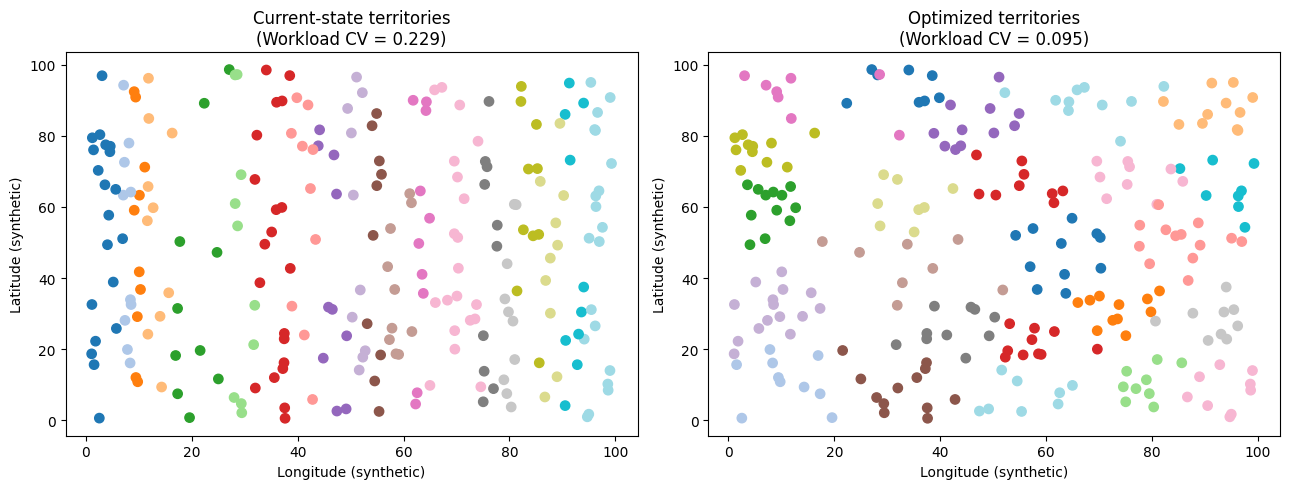

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc0 = axes[0].scatter(zips["lon"], zips["lat"], c=zips["baseline_rep"], cmap="tab20", s=45)
axes[0].set_title(f"Current-state territories\n(Workload CV = {baseline_cv:.3f})")
axes[0].set_xlabel("Longitude (synthetic)")
axes[0].set_ylabel("Latitude (synthetic)")

sc1 = axes[1].scatter(zips["lon"], zips["lat"], c=zips["opt_rep"], cmap="tab20", s=45)
axes[1].set_title(f"Optimized territories\n(Workload CV = {opt_cv:.3f})")
axes[1].set_xlabel("Longitude (synthetic)")
axes[1].set_ylabel("Latitude (synthetic)")

plt.tight_layout()
plt.show()


## Step 10 — Executive summary, assumptions, and limitations

**Executive summary:** Re-optimizing territory assignment against prescriber potential — rather than the geography-only process used today — cuts workload imbalance across the 24-rep field force substantially, at a modest travel-cost premium versus a pure travel-minimizing (but unbalanced) alternative. The plan is directionally robust to estimation error in potential, though a meaningful minority of realistic scenarios would still require a rep to be re-balanced — arguing for a semi-annual refresh cadence rather than a one-time redesign.

**Assumptions:**
- Travel cost is proxied by Euclidean distance to a k-means-derived rep home base, not real drive-time.
- Workload tolerance of ±15% is illustrative; the real value is a business negotiation with sales ops.
- The potential score is a synthetic composite of prescriber count × prevalence index; a real engagement would use validated third-party prescriber panels (e.g. IQVIA) and claims-based prevalence.
- The ROI translation uses an illustrative elasticity (2% scripts per potential-point of coverage improvement) that should be replaced with a client- or literature-derived elasticity before being presented as a real number.

**Limitations:**
- No territory-contiguity constraint was enforced — in reality, reps prefer geographically contiguous, drivable territories, not just balanced-but-scattered zip lists. A real version would add contiguity via a graph-based constraint or post-processing step.
- CBC is adequate here (240 zips × 24 reps); a national rollout (thousands of zips) would need a commercial solver or a cluster-then-optimize decomposition.
- The Monte Carlo test only perturbs potential, not travel cost or rep attrition — a fuller robustness test would vary all three.

**Future improvements:** add real drive-time via a routing API, enforce territory contiguity, and re-run the optimization on a rolling (e.g. semi-annual) basis rather than as a one-off.
